In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os
from scipy.stats import gaussian_kde

In [4]:
# Parameters
n_population = 500  # Full population size
n_sample = 100  # Observed sample size
instrument_strength = 0.5  # Strength of the instrument's correlation with education

def model(p_education: float = 2., ability_impact_wage: float = None, ability_impact_education: float = None):
    # Generate true population data
    ability = np.random.normal(0, 1, n_population)  # Unobserved ability factor
    if ability_impact_wage is None:
        ability_impact_wage = np.random.uniform(0.5, 5)  # 3
    if ability_impact_education is None:
        ability_impact_education = np.random.uniform(0.1, 1)  # 0.8
    
    # Instrument: distance to nearest college (affects education but not wages directly)
    distance_to_college = np.clip(np.random.normal(10, 5, n_population), 1, 100)
    
    # Education is influenced by ability and distance to college (the instrument)
    education = 12 + ability_impact_education * ability - instrument_strength * distance_to_college + np.random.normal(0, 1, n_population)
    education[education < 0] = 0  # Education cannot be negative
    
    # Wages depend on education, and ability (ability is unobserved)
    true_wages = 30 + p_education * education + ability_impact_wage * ability + np.random.normal(0, 2, n_population)
    true_wages[true_wages < 0] = 0  # Wages cannot be negative
    
    # Create a participation probability based on ability and age
    participation_prob = np.clip(0.2 + 0.2 * ability, 0, 1)
    participation = np.random.binomial(1, participation_prob, n_population)

    # Create observed sample (sample where individuals' wages are observed)
    observed_indices = np.where(participation == 1)[0]
    _n_sample = min(n_sample, len(observed_indices))
    #if _n_sample < n_sample:
    #    print(f'Warning: Sample size reduced to {_n_sample} due to insufficient participation.')
    observed_sample_indices = np.random.choice(observed_indices, _n_sample, replace=False)
    
    # Create the observed sample data
    observed_data = pd.DataFrame({
        'education': education[observed_sample_indices],
        'distance_to_college': distance_to_college[observed_sample_indices],  # Instrument
        'true_wages': true_wages[observed_sample_indices],  # Actual wages
    })
    
    # Full population data (for reference)
    population_data = pd.DataFrame({
        'education': education,
        'distance_to_college': distance_to_college,  # Instrument
        'true_wages': true_wages,  # Actual wages for the full population
        'participation': participation  # Whether they are in the labor market
    })
    return observed_data, population_data

In [5]:
np.random.seed(42)
true_param = 2.0
obs, pop = model(true_param, ability_impact_education=0.8, ability_impact_wage=3)

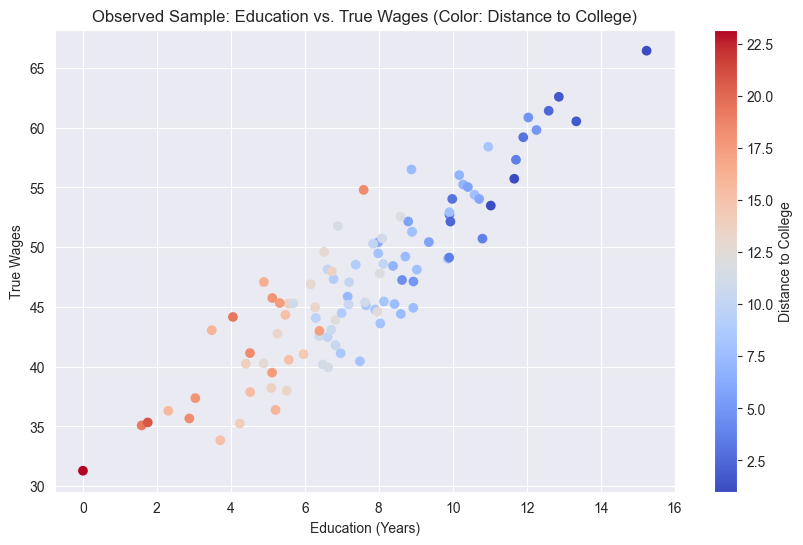

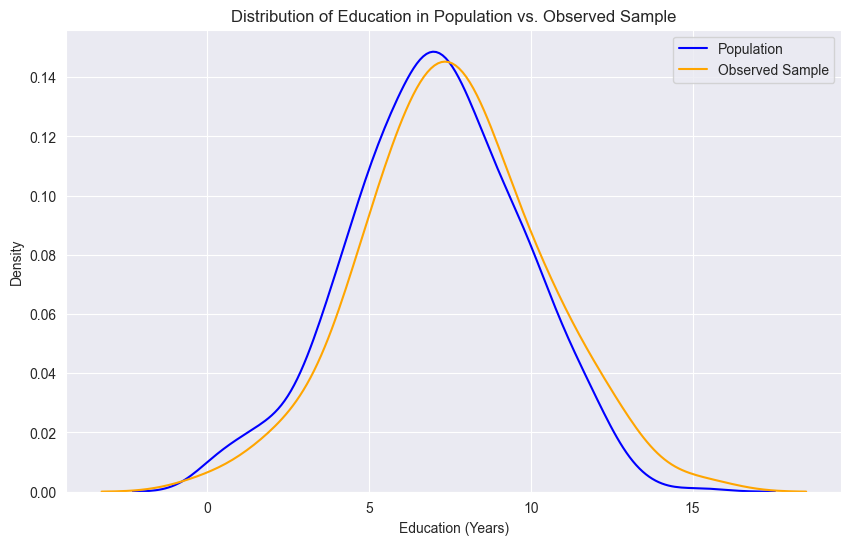

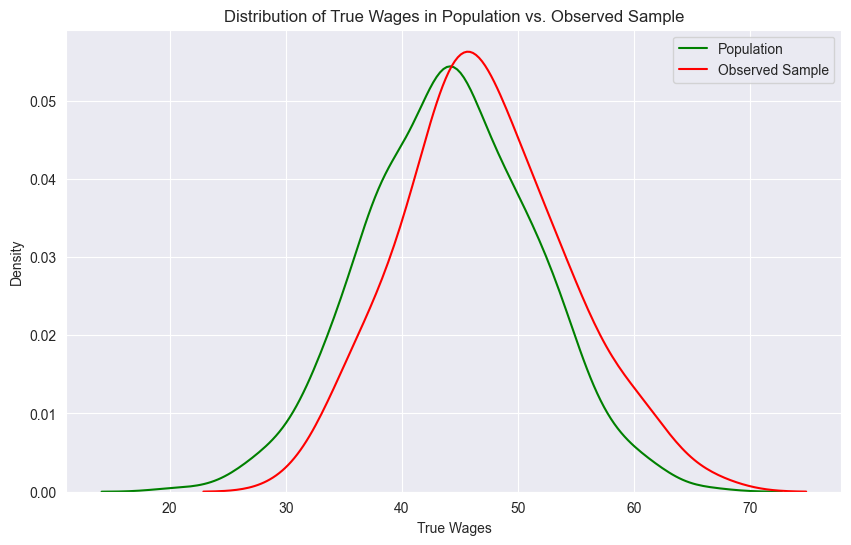

In [6]:
# Visualizing the relationship between education and true wages in the observed sample
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x=obs['education'], y=obs['true_wages'], c=obs['distance_to_college'], cmap='coolwarm')
plt.title('Observed Sample: Education vs. True Wages (Color: Distance to College)')
plt.xlabel('Education (Years)')
plt.ylabel('True Wages')
plt.colorbar(scatter, label='Distance to College')
plt.show()

# Visualizing the distribution of education in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['education'], label='Population', color='blue')
sns.kdeplot(obs['education'], label='Observed Sample', color='orange')
plt.title('Distribution of Education in Population vs. Observed Sample')
plt.xlabel('Education (Years)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Visualizing the distribution of wages in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['true_wages'], label='Population', color='green')
sns.kdeplot(obs['true_wages'], label='Observed Sample', color='red')
plt.title('Distribution of True Wages in Population vs. Observed Sample')
plt.xlabel('True Wages')
plt.ylabel('Density')
plt.legend()
plt.show()

In [7]:
# Prepare the data for OLS analysis
# Define dependent variable (outcome) and independent variable (education)
Y = obs['true_wages']

#  Use education to estimate wages
ols = sm.OLS(Y, sm.add_constant(obs['education'])).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             true_wages   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     432.9
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           9.88e-38
Time:                        17:19:12   Log-Likelihood:                -251.92
No. Observations:                 100   AIC:                             507.8
Df Residuals:                      98   BIC:                             513.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.5808      0.894     33.083      0.000      27.806      31.355
education      2.3181      0.111     20.805      0.000       2.097       2.539
==============================================================================
Omnibus:                        1.347   Durbin-Watson:                   1.915
Prob(Omnibus):                  0.510   Jarque-Bera (JB):                1.188
Skew:                           0.090   Prob(JB):                        0.552
Kurtosis:                       2.498   Cond. No.                         24.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
# Prepare the data for IV analysis
# Define dependent variable (outcome) and independent variable (education)

# Add a constant to the independent variable
X = sm.add_constant(obs['education'])

# Instrument: distance_to_college
Z = sm.add_constant(obs['distance_to_college'])  # Instrument for education

# First stage: Predict education using the instrument (distance to college)
first_stage = sm.OLS(obs['education'], Z).fit()
obs['predicted_education'] = first_stage.predict(Z)

# Second stage: Use predicted education to estimate wages
second_stage = sm.OLS(Y, sm.add_constant(obs['predicted_education'])).fit()

# Display the results of the instrumental variable analysis
second_stage.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             true_wages   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     122.4
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           6.06e-19
Time:                        17:19:12   Log-Likelihood:                -295.87
No. Observations:                 100   AIC:                             595.7
Df Residuals:                      98   BIC:                             601.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  31.0104      1.527     20.310      0.000      27.980      34.040
predicted_education     2.1287      0.192     11.063      0.000       1.747       2.511
==============================================================================
Omnibus:                        5.714   Durbin-Watson:                   1.943
Prob(Omnibus):                  0.057   Jarque-Bera (JB):                5.298
Skew:                           0.557   Prob(JB):                       0.0707
Kurtosis:                       3.181   Cond. No.                         26.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Use BayesFlow

In [9]:
import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [10]:
posterior_samples_dict = {
    'instrument_observed': None,
    'no_instrument_observed': None,
}

In [30]:
instrument_observed = False

In [31]:
def generative_model(n_samples: int = None, param_batch: np.ndarray = None):
    if param_batch is None:
        if n_samples is None:
            raise ValueError
        param_batch = np.random.uniform(0, 5, size=(n_samples, 1))
    
    data = np.zeros((len(param_batch), n_sample, 3 if instrument_observed else 2))
    for i, param in enumerate(param_batch):
        data_i, _ = model(param[0])  # only one parameter
        if instrument_observed:
            data_i = data_i[['true_wages', 'education', 'distance_to_college']].values
        else:
            data_i = data_i[['true_wages', 'education']].values
        if data_i.shape[0] < n_sample:
            data_i = np.pad(data_i, ((0, n_sample - data_i.shape[0]), (0, 0)), mode='constant', constant_values=-0.1)
        data[i] = data_i
    return {'sim_data': data, 'prior_draws': param_batch}

In [32]:
param_names = ['education']
param_names

['education']

In [33]:
summary_net = DeepSet(summary_dim=2)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=3,
    permutation="learnable"
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [34]:
np.random.seed(42)
_sim_data = generative_model(1000)
prior_mean = _sim_data['prior_draws'].mean(axis=0)
prior_std = _sim_data['prior_draws'].std(axis=0)
x_mean = np.log1p(_sim_data['sim_data']).mean(axis=0)
x_std = np.log1p(_sim_data['sim_data']).std(axis=0)

In [35]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    x = forward_dict["sim_data"]
    x = np.log1p(x)
    x = (x - x_mean) / x_std
    out_dict = {
        'summary_conditions': x.astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

In [36]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    #checkpoint_path='amortizer_education_IV' if instrument_observed else 'amortizer_education',
)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [37]:
%%time
np.random.seed(42)
offline_data = generative_model(10000)
valid_data = generative_model(256)
prior_draws = valid_data['prior_draws']

CPU times: user 3.12 s, sys: 23.5 ms, total: 3.14 s
Wall time: 3.15 s


In [38]:
if True: #not os.path.exists(trainer.checkpoint_path):
    history = trainer.train_offline(
        simulations_dict=offline_data,
        epochs=30,
        batch_size=128,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

Training epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 0.019


Training epoch 2:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: -0.632


Training epoch 3:   0%|          | 0/79 [00:00<?, ?it/s]

...

INFO:root:Validation, Epoch: 25, Loss: -1.420


Training epoch 26:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 26, Loss: -1.437


Training epoch 27:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 27, Loss: -1.429
INFO:root:Early stopping triggered.


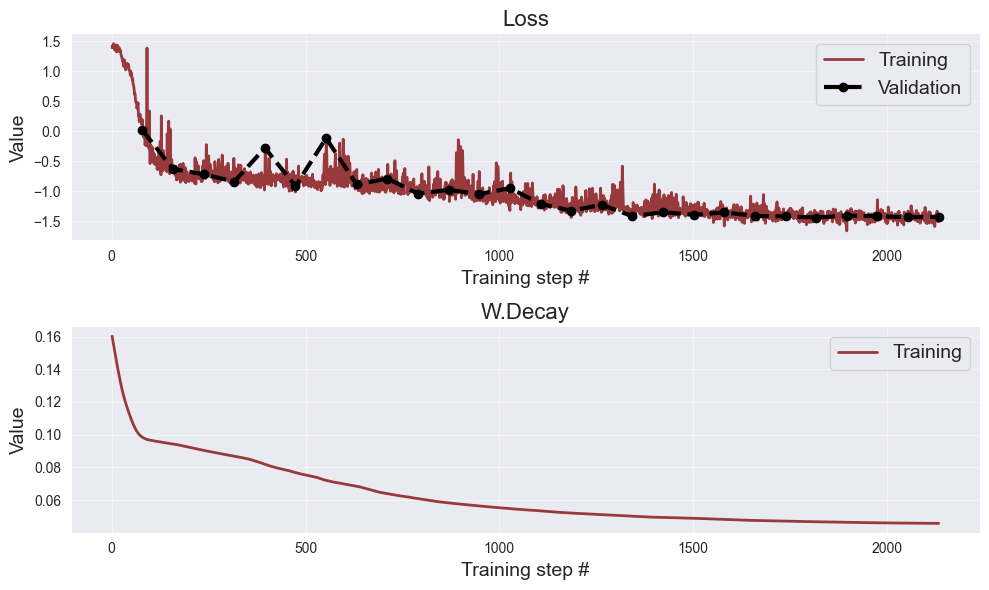

In [39]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [40]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean

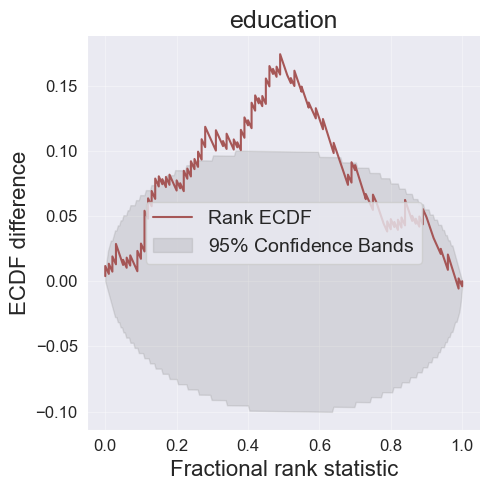

In [41]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names);

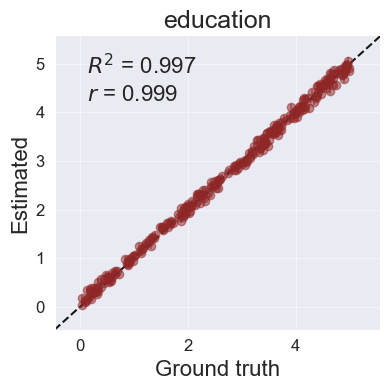

In [42]:
bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names);

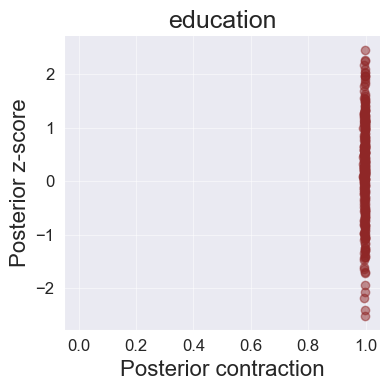

In [43]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

## Test Data

In [44]:
if instrument_observed:
    test_data = {'sim_data': obs[['true_wages', 'education', 'distance_to_college']].values[np.newaxis]}
else:
    test_data = {'sim_data': obs[['true_wages', 'education']].values[np.newaxis]}
posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=1000)
posterior_samples = posterior_samples * prior_std + prior_mean

if instrument_observed:
    posterior_samples_dict['instrument_observed'] = posterior_samples.copy()
else:
    posterior_samples_dict['no_instrument_observed'] = posterior_samples.copy()

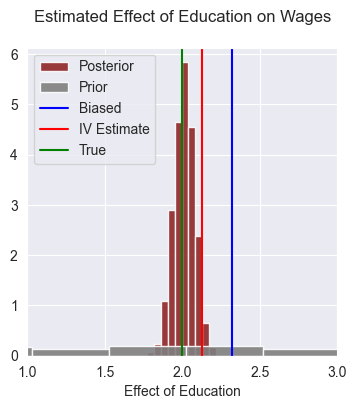

In [45]:
fig = plt.figure(figsize=(4, 4))
plt.hist(posterior_samples, density=True, alpha=0.9, color="#8f2727", label='Posterior')
plt.hist(prior_draws, density=True, alpha=0.9, color="gray", label='Prior')
 
# add references
plt.axvline(ols.params['education'], color='b', label='Biased')
plt.axvline(second_stage.params['predicted_education'], color='r', label='IV Estimate')
plt.axvline(true_param, color='g', label='True')
plt.legend()
plt.xlabel('Effect of Education')
plt.xlim(1,3)
plt.title(f'Estimated Effect of Education on Wages\n{"with Instruments Observed" if instrument_observed else ""}')
plt.show()

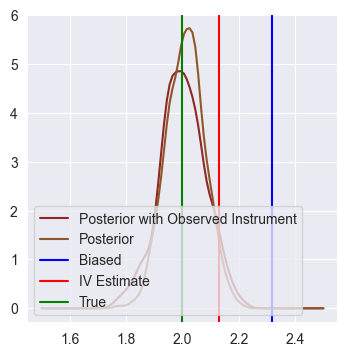

In [48]:
if posterior_samples_dict['instrument_observed'] is not None and posterior_samples_dict['no_instrument_observed'] is not None:
    fig = plt.figure(figsize=(4, 4))
    x = np.linspace(1.5, 2.5, 100)
    
    kde = gaussian_kde(posterior_samples_dict['instrument_observed'].flatten())
    plt.plot(x, kde(x), color='#8f2727', label='Posterior with Observed Instrument')
    
    kde_no = gaussian_kde(posterior_samples_dict['no_instrument_observed'].flatten())
    plt.plot(x, kde_no(x), color='#8f5727', label='Posterior')
    
    plt.axvline(ols.params['education'], color='b', label='Biased')
    plt.axvline(second_stage.params['predicted_education'], color='r', label='IV Estimate')
    plt.axvline(true_param, color='g', label='True')
    
    plt.legend(loc='lower left')
    plt.show()